In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import os
%matplotlib inline
os.getcwd()
file = '../Scenario_Analysis.xlsx'
df = pd.read_excel(file, sheet_name='MethanolMarginal')
df = df.loc[:, ~df.columns.str.contains(r'\.\d+$')]
df = df.set_index(df.columns[0])

In [5]:
df

,Baseline,NoStorageCO2,NoStorageALL,H2,BioFixed,CO2Trans,ElectricityPrice
Week,,,,,,,
1,820.491644,821.411101,801.427241,820.352332,698.258724,831.198844,52.307083
2,815.809099,817.410069,689.420100,815.809099,696.176678,826.516299,55.798036
3,871.268796,871.065964,823.246532,870.686693,745.992356,882.212995,69.363512
4,897.702420,905.808833,933.376307,897.702420,772.653132,908.409620,74.571190
5,768.421368,770.916094,749.467449,768.421368,650.351477,779.128568,66.711369
6,700.493200,702.005667,695.579936,728.971701,584.550139,711.200400,51.036548
7,671.528470,676.470863,649.491933,724.033155,558.166889,680.300750,57.284167
8,673.358469,677.078262,642.690685,726.430752,558.845549,682.130749,55.897738
9,676.022794,679.181309,701.575542,724.263423,565.395125,684.664325,48.601012


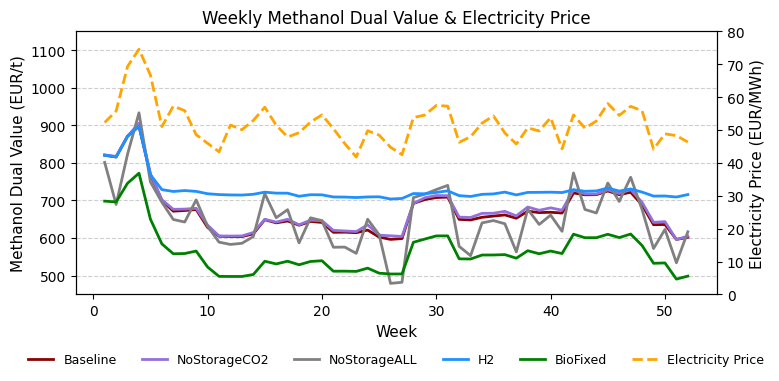

In [6]:
import matplotlib.pyplot as plt

def plot_weekly_methanol(df, scenarios, scenario_colors=None):
    if scenario_colors is None:
        scenario_colors = {}

    fig, ax1 = plt.subplots(figsize=(8, 4))

    # --- Plot scenarios on primary axis ---
    for scen in scenarios:
        ax1.plot(
            df.index,
            df[scen],
            label=scen,
            linewidth=2,
            color=scenario_colors.get(scen, None)
        )

    ax1.set_xlabel("Week", fontsize=11)
    ax1.set_ylabel("Methanol Dual Value (EUR/t)", fontsize=11)
    ax1.set_title("Weekly Methanol Dual Value & Electricity Price", fontsize=12)
    ax1.set_ylim(450, 1150)

    ax1.grid(axis="y", linestyle="--", alpha=0.6)
    ax1.set_axisbelow(True)

    # --- Secondary axis for electricity price ---
    ax2 = ax1.twinx()
    ax2.plot(
        df.index,
        df["ElectricityPrice"],
        color="orange",
        linestyle="--",
        linewidth=2,
        label="Electricity Price"
    )
    ax2.set_ylim(0, 80)
    ax2.set_ylabel("Electricity Price (EUR/MWh)", fontsize=11)

    # --- Combined legend ---
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(
        lines1 + lines2,
        labels1 + labels2,
        loc="upper center",
        bbox_to_anchor=(0.5, -0.18),
        ncol=len(scenarios) + 1,
        frameon=False,
        fontsize=9
    )

    fig.tight_layout()
    return fig  # <-- IMPORTANT: return figure (don’t show here)


# -------------------- One cell usage --------------------
scenario_colors = {
    "Baseline":  "darkred",
    "NoStorageCO2": "mediumpurple",
    "NoStorageALL": "gray",
    "H2":        "dodgerblue",
    "BioFixed":  "green",
    "CO2Trans": "purple"
}

scenarios = ["Baseline", "NoStorageCO2", "NoStorageALL", "H2", "BioFixed"]

fig = plot_weekly_methanol(df, scenarios, scenario_colors)

fig.savefig("MethanolDualWeekly.pdf", format="pdf", bbox_inches="tight")
plt.show()


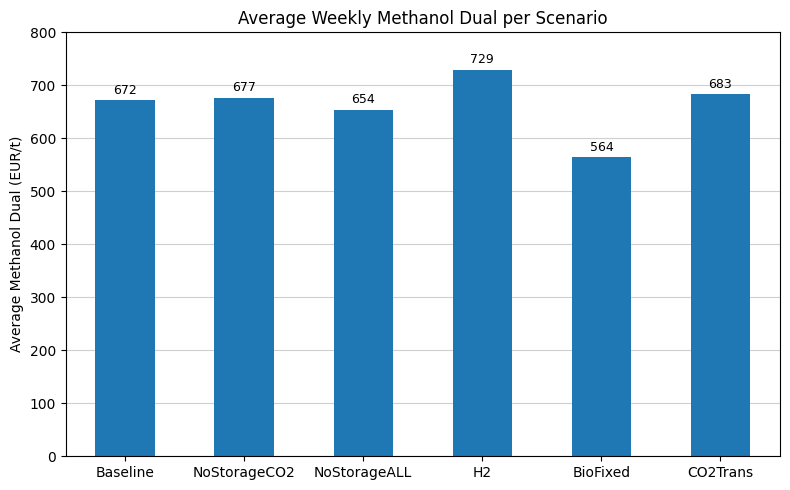

In [7]:
import matplotlib.pyplot as plt

# Select only scenario columns (exclude ElectricityPrice)
scenario_cols = [c for c in df.columns if c != "ElectricityPrice"]

# Compute averages
scenario_means = df[scenario_cols].mean().round(0)

fig, ax = plt.subplots(figsize=(8,5))

scenario_means.plot(kind='bar', ax=ax)

# Labels & title
ax.set_ylabel("Average Methanol Dual (EUR/t)")
ax.set_title("Average Weekly Methanol Dual per Scenario")

# Grid behind bars
ax.grid(axis='y', alpha=0.6)
ax.set_axisbelow(True)

# X & Y ticks
ax.set_xticklabels(ax.get_xticklabels(), rotation=0, ha='center')
ax.set_yticks(range(0, int(scenario_means.max()) + 100, 100))

# Numeric labels on bars
for i, value in enumerate(scenario_means):
    ax.text(
        i,
        value + (value * 0.01),
        f"{int(value)}",
        ha='center', va='bottom', fontsize=9
    )

plt.tight_layout()
plt.savefig("MethanolDualAverage.pdf", format="pdf", bbox_inches="tight")
plt.show()
